In [1]:
import sys

sys.path.append('../src/')
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import pysindy as ps
from libselection.utils import *
from libselection import *
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib as mpl
import sympy as sp

In [2]:
Avh = np.load("../Data/16_roll_Wi_3.5.npy", allow_pickle=True)
t = Avh[:, 0]
Avh = Avh[:,1:]

active_idx = [0, 1]  # Dynamically active modes
# first two POD modes
r = 2
tfrac = 0.8  # Proportion of the data to train on
M = len(t)
M_train = int(len(t) * tfrac)
t_train = t[:M_train]
t_test = t[M_train:]

pod_names = ["a_{}".format(1+i) for i in (active_idx)]
# pod_names = ['x', 'y']

# Normalize the trajectories for simplicity
normalization = sum(np.amax(abs(Avh), axis=0)[active_idx])
x = np.zeros((Avh.shape[0], r))
    
x[:, 0] = Avh[:, 0] / normalization
x[:, 1] = Avh[:, 1] / normalization


x_train = x[:M_train, :]
x0_train = x[0, :]
x_test = x[M_train:, :]
x0_test = x[M_train, :]

library_gen = ps.PolynomialLibrary(degree=4) # + ps.FourierLibrary(n_frequencies=2)
D = np.array(library_gen.fit_transform(x_train))
name_tag = np.array(library_gen.get_feature_names(pod_names))
dt = 1.0
x_dot = non_uniform_diff(x_train, t_train)


_, No_D = D.shape
print('No_D5=',len(D[0,:]),'rank=',np.linalg.matrix_rank(D), D[0,:].shape == np.linalg.matrix_rank(D))
print('--------------------')
print('Case:',name_tag)
print('No_D5=',len(D[0,:]),'rank=',np.linalg.matrix_rank(D), D[0,:].shape == np.linalg.matrix_rank(D))

No_D5= 15 rank= 15 [ True]
--------------------
Case: ['1' 'a_1' 'a_2' 'a_1^2' 'a_1 a_2' 'a_2^2' 'a_1^3' 'a_1^2 a_2' 'a_1 a_2^2'
 'a_2^3' 'a_1^4' 'a_1^3 a_2' 'a_1^2 a_2^2' 'a_1 a_2^3' 'a_2^4']
No_D5= 15 rank= 15 [ True]


In [10]:
# lib_gen = ps.WeakPDELibrary(
#     function_library=ps.PolynomialLibrary(degree=3, include_bias=False),
#     spatiotemporal_grid=t_train,
#     derivative_order=1,
#     implicit_terms=True
# ).fit(x_train)

lib_gen = ps.PDELibrary(
    function_library=ps.PolynomialLibrary(degree=3, include_bias=False),
    temporal_grid=t_train,
    derivative_order=1,
    implicit_terms=True
).fit(x_train)

lib_gen.get_feature_names(['x', 'y'])

c:\Users\fabio\anaconda3\envs\pysindy2_env\Lib\site-packages\pysindy\utils\axes.py:126: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(


['x',
 'y',
 'x^2',
 'x y',
 'y^2',
 'x^3',
 'x^2 y',
 'x y^2',
 'y^3',
 'x_t',
 'y_t',
 'xx_t',
 'yx_t',
 'x^2x_t',
 'x yx_t',
 'y^2x_t',
 'x^3x_t',
 'x^2 yx_t',
 'x y^2x_t',
 'y^3x_t',
 'xy_t',
 'yy_t',
 'x^2y_t',
 'x yy_t',
 'y^2y_t',
 'x^3y_t',
 'x^2 yy_t',
 'x y^2y_t',
 'y^3y_t']

In [11]:
sindy_opt = ps.SINDyPI(reg_weight_lam=1e-4)
model = ps.SINDy(
    optimizer=sindy_opt,
    feature_library=lib_gen,
    # differentiation_method=ps.FiniteDifference(order=2),
)

model.fit(x_train,t=dt)


c:\Users\fabio\anaconda3\envs\pysindy2_env\Lib\site-packages\pysindy\utils\axes.py:126: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(


Model  0
Model  1
Model  2
Model  3
Model  4
Model  5
Model  6
Model  7
Model  8
Model  9
Model  10
Model  11
Model  12
Model  13
Model  14
Model  15
Model  16
Model  17
Model  18
Model  19
Model  20
Model  21
Model  22
Model  23
Model  24
Model  25
Model  26
Model  27
Model  28


AttributeError: 'PDELibrary' object has no attribute 'is_uniform'

AttributeError: 'PDELibrary' object has no attribute 'is_uniform'

AttributeError: 'PDELibrary' object has no attribute 'is_uniform'

In [12]:
model.print()

(x0) = 0.185 x1 + -0.001 x0^2 + -0.009 x0 x1 + 0.014 x1^2 + 1.325 x0^3 + 0.484 x0^2 x1 + 0.755 x0 x1^2 + -1.524 x1^3 + 2.283 x0_t + -38.141 x1_t + 0.261 x0x0_t + -0.276 x0x1_t + 67.955 x0^2x1_t + 11.598 x1^2x1_t
(x1) = -0.044 x0 + -0.002 x0^2 + 0.002 x0 x1 + 1.554 x0^3 + 0.568 x0^2 x1 + -0.643 x0 x1^2 + 1.516 x1^3 + 37.052 x0_t + 7.494 x1_t + 0.327 x1x0_t + -10.096 x0^2x0_t + 4.466 x0 x1x0_t + -66.292 x1^2x0_t + -2.189 x0^2x1_t + 1.975 x1^2x1_t + 0.405 x0 x1^2x1_t
(x0^2) = 0.002 x0 + 0.001 x1 + 0.223 x0 x1 + 0.242 x1^2 + -0.001 x0^2 x1 + 0.007 x0 x1^2 + 0.002 x1^3 + -0.045 x0_t + -5.198 x0x0_t + -7.994 x1x0_t + -25.276 x0 x1^2x0_t + -41.118 x0x1_t + -8.552 x1x1_t + 41.221 x0^3x1_t + -11.041 x0^2 x1x1_t + -29.641 x0 x1^2x1_t + 22.337 x1^3x1_t
(x0 x1) = -0.001 x0 + 0.003 x1 + -0.008 x0^2 + -0.001 x0^3 + -0.003 x0^2 x1 + 0.005 x0 x1^2 + -0.006 x1^3 + -0.038 x1_t + 16.852 x0x0_t + 3.518 x1x0_t + 18.728 x0^3x0_t + -36.696 x0^2 x1x0_t + -24.736 x1^3x0_t + 2.798 x0x1_t + -18.137 x1x1_t + -22.

c:\Users\fabio\anaconda3\envs\pysindy2_env\Lib\site-packages\pysindy\pysindy.py:600: UserWarning: SINDy.differentiate is deprecated.  Call the differentiation_method parameter
  warnings.warn(


9
10


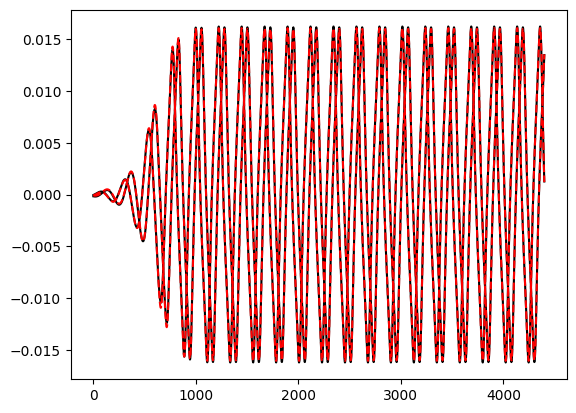

In [13]:
# Plot the fit of the derivative
x_dot_train = model.differentiate(x_train, t_train)
x_dot_train_pred = model.predict(x_train)  # will default to d/dt of all the features
plt.figure()
plt.plot(t_train, x_dot_train, 'k')
for i, xp in enumerate( x_dot_train_pred.T):
    err = np.min([np.linalg.norm(xt - xp)/np.linalg.norm(xp) for xt in x_dot_train.T])
    if err < 0.5:
        print(i)
        plt.plot(t_train, xp, 'r--')

In [14]:
def fix_expr(expr):
    # 1. adiciona * quando tem espaço
    expr = re.sub(r'(\w)\s+(\w)', r'\1*\2', expr)
    # 2. adiciona * quando duas variáveis/termos estão colados (ex: x0x1 → x0*x1)
    expr = re.sub(r'([a-zA-Z0-9\)\]])([a-zA-Z\(])', r'\1*\2', expr)
    return expr

# parsed = [sympify(fix_expr(e)) for e in exprs]

In [15]:
features = model.get_feature_names()
# features[0] = "1"
features_copy = list(np.copy(features))
nfeatures = len(features)
features_formatted = []
# Need to put multiplication between terms for sympy
for i in range(nfeatures):
    for j in range(r):
        # Overkill to make sure all the x0, x1, etc. get replaced
        temp_string = features[i].replace("x" + str(j) + "x", "x" + str(j) + " * x")
        temp_string = temp_string.replace("x" + str(j) + "x", "x" + str(j) + " * x")
        temp_string = temp_string.replace("x" + str(j) + "x", "x" + str(j) + " * x")
        temp_string = temp_string.replace("x" + str(j) + "x", "x" + str(j) + " * x")
        features[i] = temp_string
    features_formatted.append(temp_string)
features = features_copy
print(features)
print(features_formatted)
coefs = model.coefficients()
sym_features = [sp.Symbol(fix_expr(feature)) for feature in features]
sym_theta = [sp.Symbol(fix_expr(feature)) for feature in features]

[np.str_('x0'), np.str_('x1'), np.str_('x0^2'), np.str_('x0 x1'), np.str_('x1^2'), np.str_('x0^3'), np.str_('x0^2 x1'), np.str_('x0 x1^2'), np.str_('x1^3'), np.str_('x0_t'), np.str_('x1_t'), np.str_('x0x0_t'), np.str_('x1x0_t'), np.str_('x0^2x0_t'), np.str_('x0 x1x0_t'), np.str_('x1^2x0_t'), np.str_('x0^3x0_t'), np.str_('x0^2 x1x0_t'), np.str_('x0 x1^2x0_t'), np.str_('x1^3x0_t'), np.str_('x0x1_t'), np.str_('x1x1_t'), np.str_('x0^2x1_t'), np.str_('x0 x1x1_t'), np.str_('x1^2x1_t'), np.str_('x0^3x1_t'), np.str_('x0^2 x1x1_t'), np.str_('x0 x1^2x1_t'), np.str_('x1^3x1_t')]
['x0', 'x1', 'x0^2', 'x0 x1', 'x1^2', 'x0^3', 'x0^2 x1', 'x0 x1^2', 'x1^3', 'x0_t', 'x1_t', 'x0 * x0_t', 'x1 * x0_t', 'x0^2x0_t', 'x0 x1 * x0_t', 'x1^2x0_t', 'x0^3x0_t', 'x0^2 x1 * x0_t', 'x0 x1^2x0_t', 'x1^3x0_t', 'x0 * x1_t', 'x1 * x1_t', 'x0^2x1_t', 'x0 x1 * x1_t', 'x1^2x1_t', 'x0^3x1_t', 'x0^2 x1 * x1_t', 'x0 x1^2x1_t', 'x1^3x1_t']


In [18]:
sym_equations = []
sym_equations_rounded = []
for i in range(nfeatures):
    sym_equations.append(
        sp.solve(
            sp.Eq(sym_theta[i], sym_theta @ np.around(coefs[i], 10)),
            sym_features[i]
        )
    )
    sym_equations_rounded.append(
        sp.solve(
            sp.Eq(sym_theta[i], sym_theta @ np.around(coefs[i], 2)), sym_features[i]
        )
    )
    print(i, sym_theta[i], " = ", sym_equations_rounded[i][0])

0 x0  =  0.26*x0*x0_t - 0.01*x0*x1 + 0.76*x0*x1^2 - 0.28*x0*x1_t + 0.48*x0^2*x1 + 67.95*x0^2*x1_t + 1.33*x0^3 + 2.28*x0_t + 0.19*x1 + 0.01*x1^2 + 11.6*x1^2*x1_t - 1.52*x1^3 - 38.14*x1_t
1 x1  =  -0.04*x0 + 4.47*x0*x1*x0_t - 0.64*x0*x1^2 + 0.4*x0*x1^2*x1_t - 10.1*x0^2*x0_t + 0.57*x0^2*x1 - 2.19*x0^2*x1_t + 1.55*x0^3 + 37.05*x0_t + 0.33*x1*x0_t - 66.29*x1^2*x0_t + 1.97*x1^2*x1_t + 1.52*x1^3 + 7.49*x1_t
2 x0^2  =  -5.2*x0*x0_t + 0.22*x0*x1 + 0.01*x0*x1^2 - 25.28*x0*x1^2*x0_t - 29.64*x0*x1^2*x1_t - 41.12*x0*x1_t - 11.04*x0^2*x1*x1_t + 41.22*x0^3*x1_t - 0.04*x0_t - 7.99*x1*x0_t - 8.55*x1*x1_t + 0.24*x1^2 + 22.34*x1^3*x1_t
3 x0*x1  =  16.85*x0*x0_t + 0.01*x0*x1^2 - 37.93*x0*x1^2*x1_t + 2.8*x0*x1_t - 0.01*x0^2 - 36.7*x0^2*x1*x0_t + 18.73*x0^3*x0_t - 22.22*x0^3*x1_t + 3.52*x1*x0_t - 18.14*x1*x1_t - 0.01*x1^3 - 24.74*x1^3*x0_t - 20.11*x1^3*x1_t - 0.04*x1_t
4 x1^2  =  -8.62*x0*x0_t - 0.23*x0*x1 - 11.33*x0*x1^2*x0_t + 7.95*x0*x1_t + 0.24*x0^2 + 29.78*x0^2*x1*x0_t - 25.12*x0^2*x1*x1_t + 0.01*x0^3 

NameError: name 'x1_t' is not defined

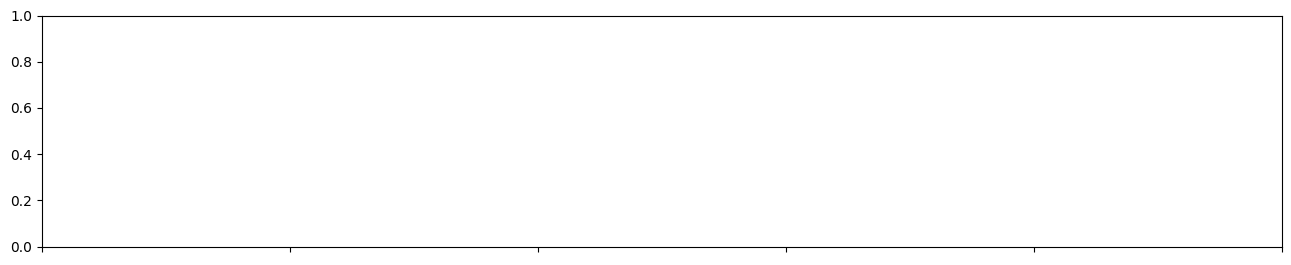

In [29]:
# Define the ODE symbol variables
t_sym = sp.symbols("t_sym")
x_sym = sp.symbols("x:%d" % r)
x_dot_sym = sp.symbols("x:%d_t" % r)
nfeatures = 2
# Need to format the above equations so that there are space between x0 * x0, x0 * x_dot0, and so on.
sym_equations_formatted = []
sym_equations_rounded_formatted = []
for i in range(nfeatures):
    for j in range(r):
        # Overkill to make sure all the x0, x1, etc. get replaced
        temp_string = str(sym_equations[i]).replace(
            "x" + str(j) + "x", "x" + str(j) + " * x"
        )
        temp_string = temp_string.replace("x" + str(j) + "x", "x" + str(j) + " * x")
        temp_string = temp_string.replace("x" + str(j) + "x", "x" + str(j) + " * x")
        temp_string = temp_string.replace("x" + str(j) + "x", "x" + str(j) + " * x")
        temp_rounded_string = str(sym_equations_rounded[i]).replace(
            "x" + str(j) + "x", "x" + str(j) + " * x"
        )
        temp_rounded_string = temp_rounded_string.replace(
            "x" + str(j) + "x", "x" + str(j) + " * x"
        )
        temp_rounded_string = temp_rounded_string.replace(
            "x" + str(j) + "x", "x" + str(j) + " * x"
        )
        temp_rounded_string = temp_rounded_string.replace(
            "x" + str(j) + "x", "x" + str(j) + " * x"
        )
        sym_equations_formatted.append(temp_string)
        sym_equations_rounded_formatted.append(temp_rounded_string)

# Now that the equations are mathematically formatted,
# solve for x_dot0 in the algebraic equation.
sym_equations_simplified = []
sym_equations_rounded_simplified = []
for i in range(nfeatures):
    sym_equations_simplified.append(
        sp.solve(
            sp.Add(
                sp.sympify(sym_equations_formatted)[i][0],
                -sp.sympify(features_formatted[i]),
            ),
            x_dot_sym,
        )
    )
    rounded = sp.solve(
        sp.Add(
            sp.sympify(sym_equations_rounded_formatted)[i][0],
            -sp.sympify(features_formatted[i]),
        ),
        x_dot_sym,
    )
    if len(rounded) != 0:
        rounded_temp = rounded[0][0]
        for a in sp.preorder_traversal(rounded):
            if isinstance(a, sp.Float):
                rounded_temp = rounded_temp.subs(a, round(a, 2))
        sym_equations_rounded_simplified.append(rounded_temp)
    else:
        sym_equations_rounded_simplified.append([])

# Plot the results for each of the models
plt.figure(figsize=(16, 3))
x0_test = x_train[0]
t_span = (t_train[0] , t_train[-1])
# x_test = solve_ivp(enzyme, t_span, x0_test, t_eval=t).y.T
# plt.plot(t, x_test, color="k", linestyle="solid", label="True")
for i in range(nfeatures):
    ax = plt.gca()
    if i != nfeatures - 1:
        ax.set_xticklabels([])
    if len(sym_equations_simplified[i]) != 0:
        ODE_Func = sp.lambdify([t_sym, x_sym], sym_equations_simplified[i][0])

        # Now simulate the system we identified
        x_test_sim = solve_ivp(ODE_Func, t_span, x0_test, t_eval=t_train).y.T
        if (
            np.linalg.norm(x_test_sim) < 1e3
            and sym_equations_rounded_simplified[i] != 0
        ):
            plt.plot(
                t,
                x_test_sim,
                linestyle="dashed",
                label=str(sp.sympify(features_formatted[i]))
                + " = "
                + str(sym_equations_rounded_simplified[i]),
            )
plt.grid(True)
plt.legend(fontsize=8)

In [30]:
x_train.shape

(4400, 2)

In [ ]:
ODE_Func.

<function _lambdifygenerated(t_sym, _Dummy_2496)>